In [23]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))
import matplotlib.pyplot as plt 
import seaborn as sns

/kaggle/input/datasets/faizanhaider01/placement-u/placement.csv
/kaggle/input/datasets/faizanhaider01/student-salary/students_dataset.csv
/kaggle/input/datasets/faizanhaider01/placement-modi/placement_modified.csv


In [24]:
df = pd.read_csv("/kaggle/input/datasets/faizanhaider01/student-salary/students_dataset.csv")

In [25]:
df.shape

(300, 3)

In [26]:
df.sample(5)

,age,salary,employed
231,20,20472,0
19,23,24232,0
102,22,17085,1
138,22,21929,0
1,22,23739,1


/tmp/ipykernel_55/1121623677.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['age'])
/tmp/ipykernel_55/1121623677.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['salary'])


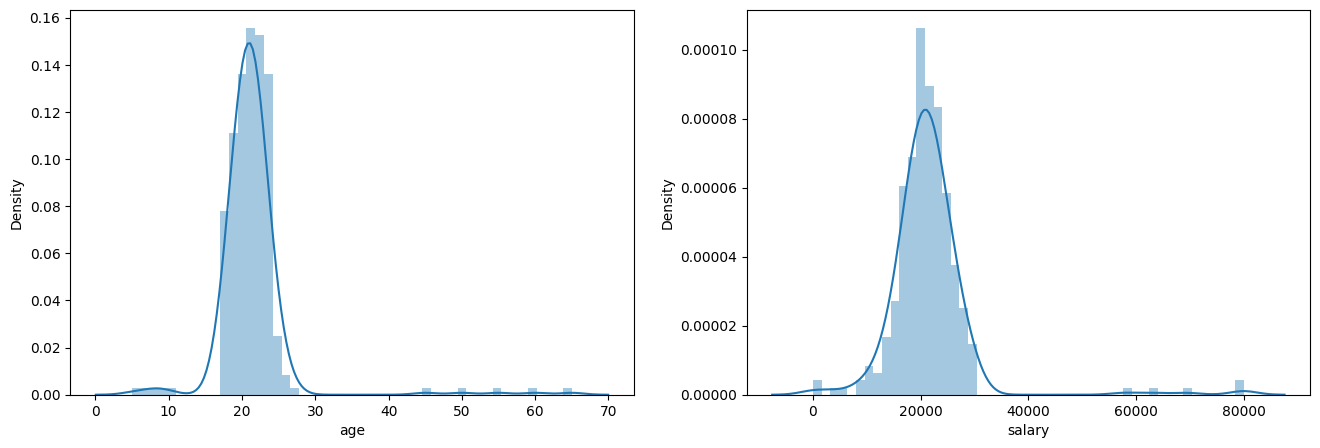

In [28]:
plt.figure(figsize=(16,5))
plt.subplot(1,2,1)
sns.distplot(df['age'])
plt.subplot(1,2,2)
sns.distplot(df['salary'])

plt.show()


In [30]:
print("Mean value of age",df['age'].mean())
print("Std value of age",df['age'].std())
print("Min value of age",df['age'].min())
print("Max value of age",df['age'].max())

Mean value of age 21.35333333333333
Std value of age 5.169548949702166
Min value of age 5
Max value of age 65


In [32]:
print("Highest_Allowed",df['age'].mean()+3*df['age'].std())
print("Lowest_Allowed",df['age'].mean()-3*df['age'].std())

Highest_Allowed 36.86198018243983
Lowest_Allowed 5.844686484226834


In [35]:
df[(df['age'] > 36.86) | (df['age'] < 5.84)]

,age,salary,employed
54,65,80000,1
159,45,57745,1
240,50,63122,1
242,5,0,1
251,55,69450,1
262,60,80000,1


# TRIMMING

In [37]:
new_df = df[(df['age']<36.86) & (df['age']>5.84)]
new_df

,age,salary,employed
0,21,19012,1
1,22,23739,1
2,20,20976,0
3,26,29311,1
4,21,19737,0
...,...,...,...
295,22,19680,1
296,24,19382,0
297,22,20732,0
298,21,22843,0


# Z-Score Formula

In [47]:
df['z_score'] = (df['age']-df['age'].mean())/df['age'].std()
df.sample(4)

,age,salary,employed,z_score
256,24,27773,1,0.511972
57,20,17198,1,-0.261789
263,20,17548,0,-0.261789
72,22,21876,1,0.125092


In [48]:
df[df['z_score']>3]

,age,salary,employed,z_score
54,65,80000,1,8.443032
159,45,57745,1,4.574222
240,50,63122,1,5.541425
251,55,69450,1,6.508627
262,60,80000,1,7.475830


In [49]:
df[df['z_score']<-3]

,age,salary,employed,z_score
242,5,0,1,-3.163397


In [50]:
df[(df['z_score']>3) | (df['z_score']<-3)]

,age,salary,employed,z_score
54,65,80000,1,8.443032
159,45,57745,1,4.574222
240,50,63122,1,5.541425
242,5,0,1,-3.163397
251,55,69450,1,6.508627
262,60,80000,1,7.475830


# Capping

In [52]:
upper_limit = df['age'].mean() + 3*df['age'].std()
lower_limit = df['age'].mean() - 3*df['age'].std()

In [53]:
print(f"Upper Limit = {upper_limit}")
print(f"Lower Limit = {lower_limit}")

Upper Limit = 36.86198018243983
Lower Limit = 5.844686484226834


In [56]:
df['age']=np.where(df['age']>36.86,upper_limit,
                  np.where(df['age']<5.84,lower_limit,df['age']))

In [58]:
df.shape  #all outliers are filled by +3 and -3 values

(300, 4)

In [62]:
df['age'].describe()

count    300.000000
mean      21.053849
std        3.286145
min        5.844686
25%       20.000000
50%       21.000000
75%       22.000000
max       36.861980
Name: age, dtype: float64